# Regression using Artificial Neural Networks

in this example we will use Keras to predict wages based on various professional and demographic factors.

In [23]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import tensorflow as tf
import matplotlib.pyplot as plt


pd.set_option('display.float_format', '{:.4f}'.format)

sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

imports ok


##Load Data

In [24]:
data = pd.read_csv('data/bcn_noise_ml_filtered.csv')
pd.options.display.max_columns = None

print(data)

                      road_id  noise_day  noise_evening  noise_night  \
0     2501123851_3587720087_0         65             60           55   
1         30295335_30295334_0         70             65           60   
2        60969463_415941159_0         70             65           65   
3       364997573_364997570_0         70             65           60   
4     2501701062_2501701155_0         70             65           65   
...                       ...        ...            ...          ...   
2312    481122454_478875365_0         50             50           45   
2313   597933817_4318426016_0         45             45           40   
2314   4318426016_597933817_0         45             45           40   
2315    8412738278_30688836_0         50             50           45   
2316    416116751_416116752_0         35             35           35   

      road_length  road_category  dist_to_main  signals  transport    pois  \
0         60.3568              5      408.5522   1.6583  

In [25]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 2317 entries, 0 to 2316
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   road_id          2317 non-null   str    
 1   noise_day        2317 non-null   int64  
 2   noise_evening    2317 non-null   int64  
 3   noise_night      2317 non-null   int64  
 4   road_length      2317 non-null   float64
 5   road_category    2317 non-null   int64  
 6   dist_to_main     2317 non-null   float64
 7   signals          2317 non-null   float64
 8   transport        2317 non-null   float64
 9   pois             2317 non-null   float64
 10  width            2317 non-null   float64
 11  height           2317 non-null   float64
 12  betw_centrality  2317 non-null   float64
 13  clos_centrality  2317 non-null   float64
 14  green_100        2317 non-null   float64
dtypes: float64(10), int64(4), str(1)
memory usage: 271.7 KB
None


In [26]:
for colname, col in data.items():
  print(colname, "min_val", col.min(), "max_val", col.max())

road_id min_val 1000063825_1000063822_0 max_val 998615843_998615795_0
noise_day min_val 35 max_val 75
noise_evening min_val 35 max_val 70
noise_night min_val 35 max_val 65
road_length min_val 1.0086858850058005 max_val 3100.6658824787464
road_category min_val 1 max_val 6
dist_to_main min_val 0.0 max_val 1061.398750553952
signals min_val 0.0322726277457739 max_val 50.0
transport min_val 0.2103553590807945 max_val 50.0
pois min_val 0.0322726277457739 max_val 50.0
width min_val 0.0 max_val 50.0
height min_val 0.0 max_val 30.0
betw_centrality min_val 0.0 max_val 0.0898145310446017
clos_centrality min_val 6.86461180242576e-05 max_val 0.0002424145487024
green_100 min_val 0.0 max_val 304.73234123093647


In [27]:
data.describe()

,noise_day,noise_evening,noise_night,road_length,road_category,dist_to_main,signals,transport,pois,width,height,betw_centrality,clos_centrality,green_100
count,2317.0000,2317.0000,2317.0000,2317.0000,2317.0000,2317.0000,2317.0000,2317.0000,2317.0000,2317.0000,2317.0000,2317.0000,2317.0000,2317.0000
mean,59.3785,57.6759,52.7622,108.1210,4.6319,172.0887,6.4029,8.0148,9.4959,27.9956,8.1853,0.0047,0.0002,10.0550
std,7.1848,7.1639,7.0227,155.7517,1.0131,182.5407,10.0253,10.2423,12.7875,14.3807,6.3409,0.0091,0.0000,24.1165
min,35.0000,35.0000,35.0000,1.0087,1.0000,0.0000,0.0323,0.2104,0.0323,0.0000,0.0000,0.0000,0.0001,0.0000
25%,55.0000,55.0000,50.0000,41.8365,4.0000,0.0000,1.3408,2.4946,1.3318,16.1630,3.4528,0.0002,0.0002,0.0000
50%,60.0000,60.0000,55.0000,79.0685,5.0000,129.7680,2.9295,4.2825,3.9639,25.7760,7.2000,0.0011,0.0002,0.6502
75%,65.0000,65.0000,60.0000,132.4348,5.0000,270.0964,6.2313,8.1706,11.5592,39.7858,12.0000,0.0045,0.0002,9.7009
max,75.0000,70.0000,65.0000,3100.6659,6.0000,1061.3988,50.0000,50.0000,50.0000,50.0000,30.0000,0.0898,0.0002,304.7323


we can see that some predictors are binary, while others are not

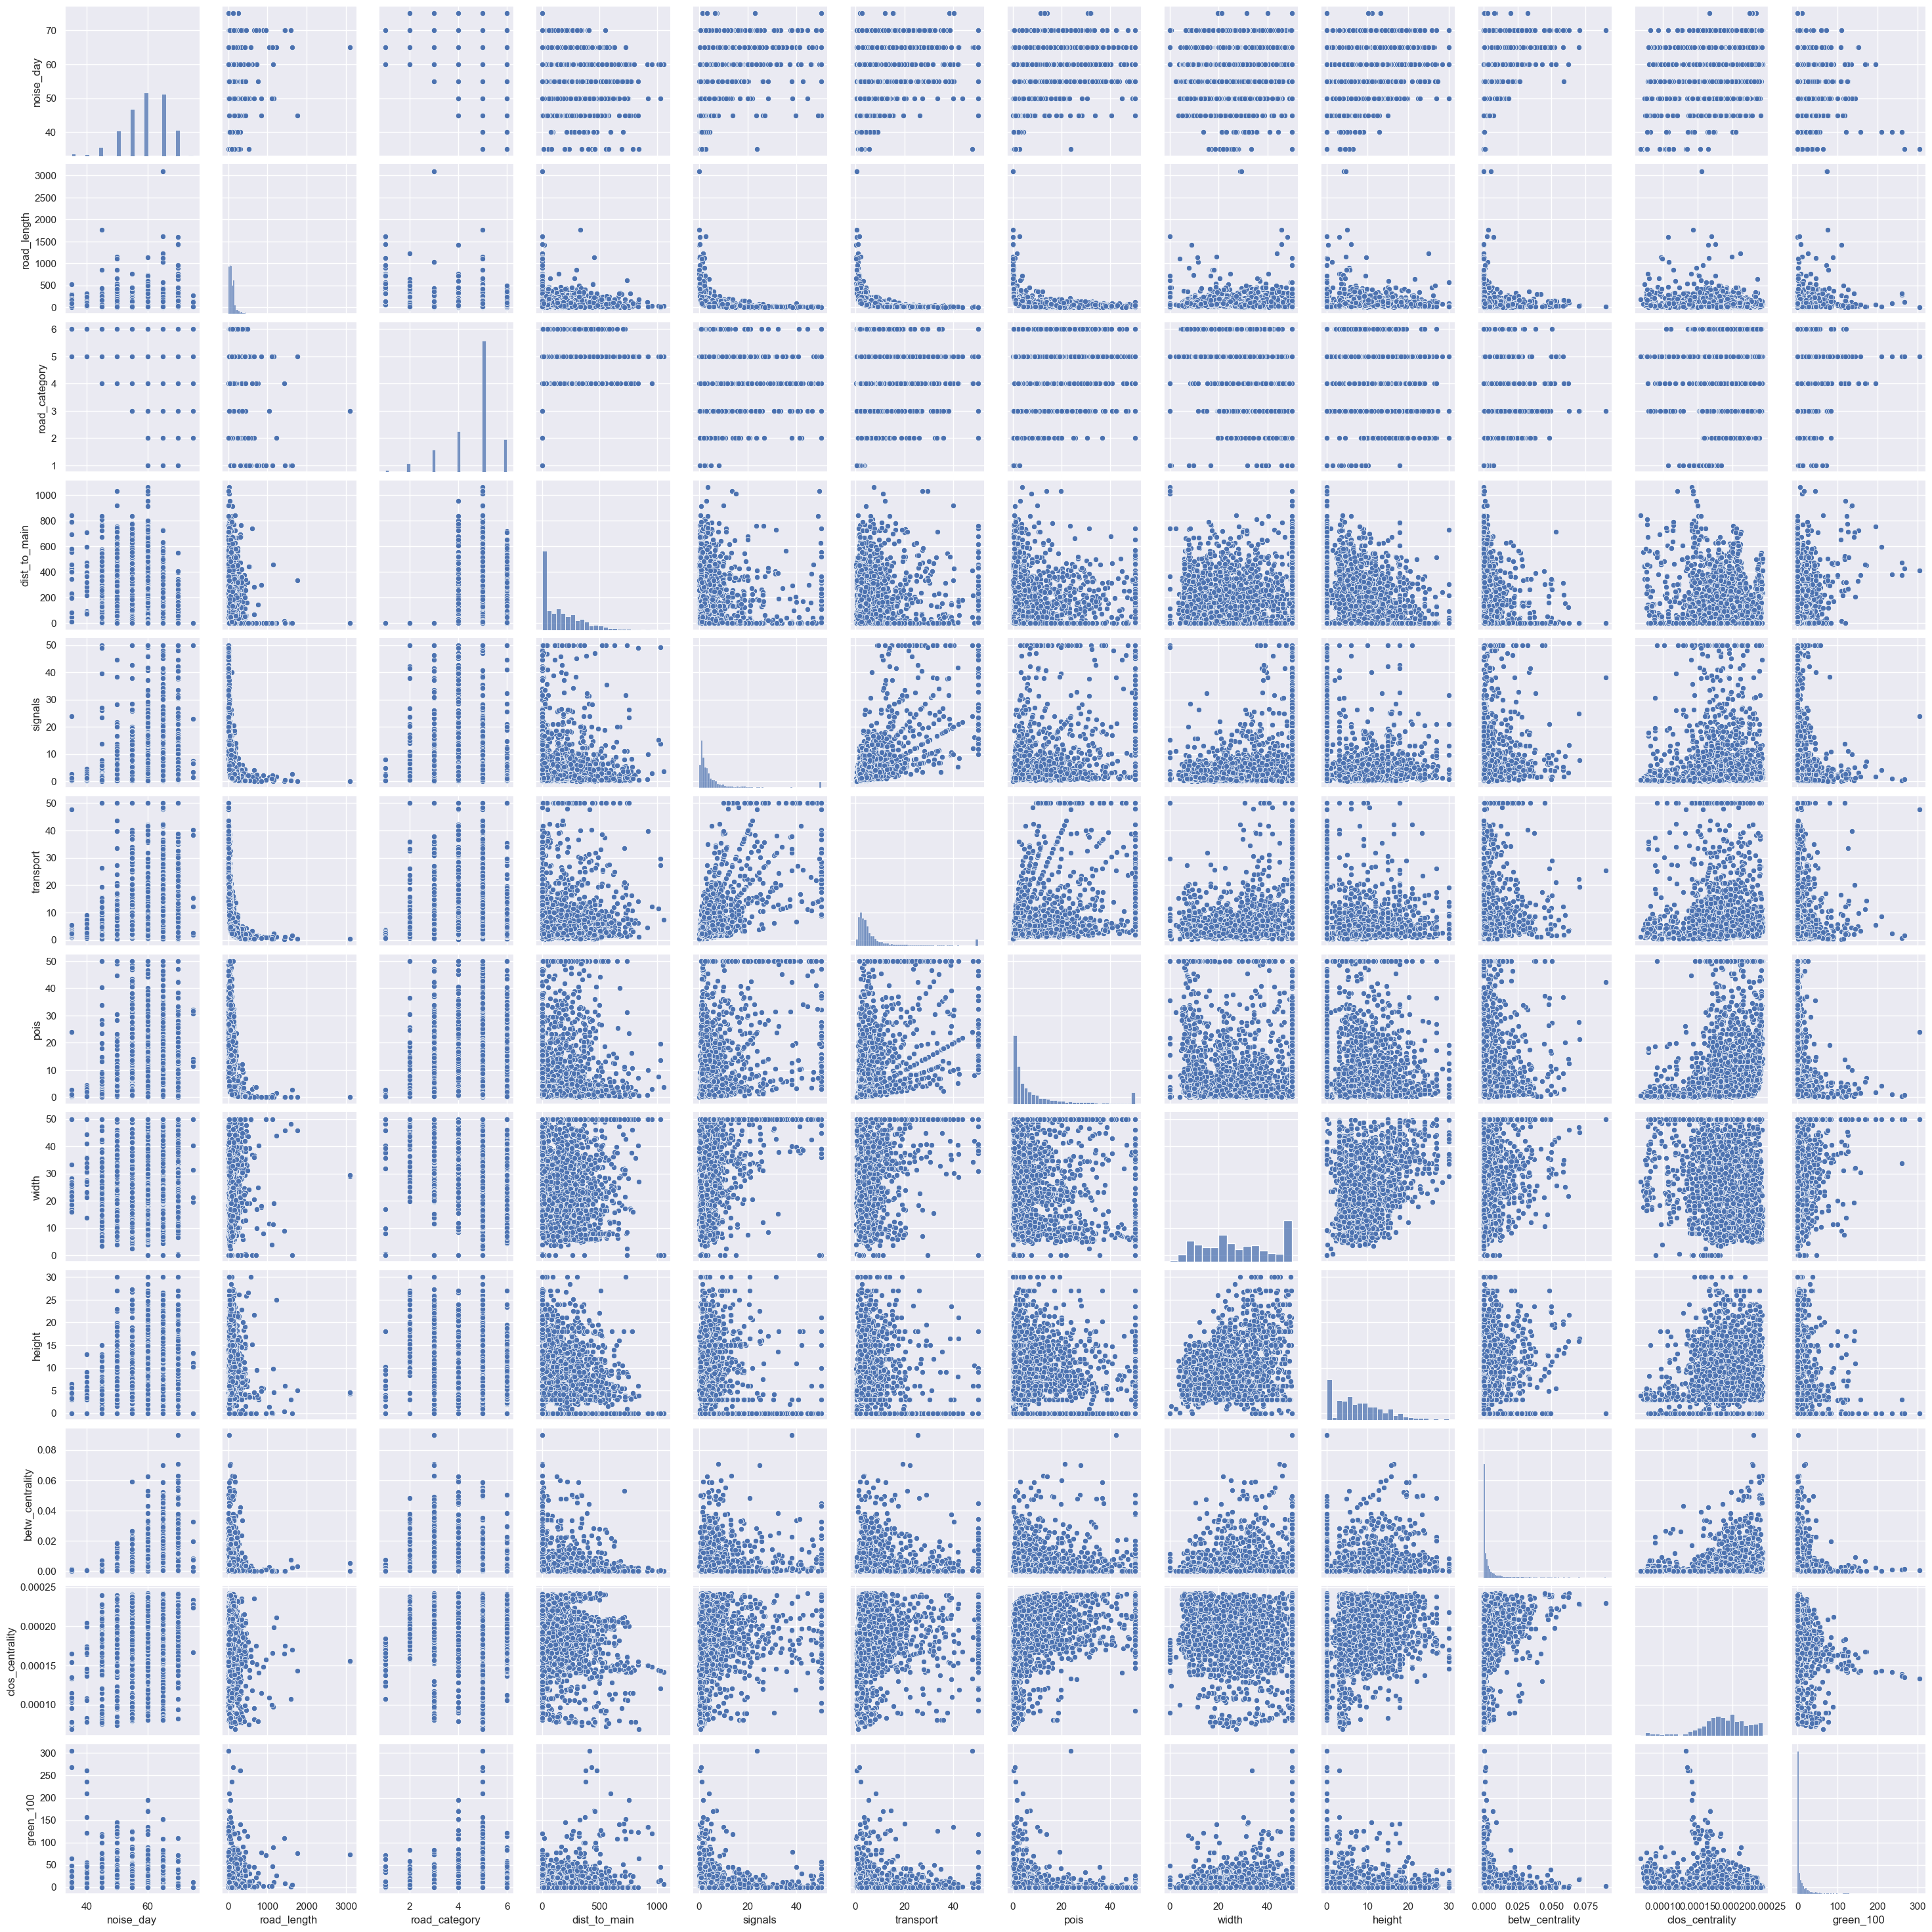

In [28]:
data_numerical = data.drop(columns=['road_id','noise_evening', 'noise_night']) # remove id and noise 
sns.pairplot(data_numerical)

We can see there is a direct relationship between age and experience, but not so much between wage and education, there is a non-linearity

##Prepare Data

**NORMALIZE INPUTS**

In [29]:
#same code as last time

#declare features
X = data.drop(columns=['road_id','noise_day','noise_evening', 'noise_night']) # keep only features

# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scalerX = StandardScaler()

# Apply the scaler to our X-features
X_scaled = scalerX.fit_transform(X)

print(X_scaled.shape)
X.head()

(2317, 11)


,road_length,road_category,dist_to_main,signals,transport,pois,width,height,betw_centrality,clos_centrality,green_100
0,60.3568,5,408.5522,1.6583,3.3166,44.7741,6.9656,8.3333,0.0048,0.0002,7.1762
1,94.7187,5,194.2816,2.1145,2.1145,1.0572,13.8369,4.8333,0.0005,0.0002,0.0000
2,78.5311,4,235.8638,2.5473,6.3682,14.0100,16.9570,10.1667,0.0081,0.0002,0.1203
3,42.7993,5,265.7832,2.3355,9.3419,2.3355,0.0000,0.0000,0.0000,0.0002,1.2454
4,130.4282,6,20.7560,3.0679,2.3009,17.6404,7.9140,7.4400,0.0002,0.0002,1.1150


In [30]:
#declare regression target
y = data.loc[:,"noise_day"].to_numpy()

y = y.reshape(-1, 1)

from sklearn.preprocessing import MinMaxScaler
scalerY = MinMaxScaler()

#In this case it makes sense to use MinMax scaling because the noise levels seem like a relative range
# Apply the scaler to our Y-features
y_scaled = scalerY.fit_transform(y)

print(y_scaled.shape)


(2317, 1)


**SPLIT INTO TRAIN AND TEST**

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size = 0.2, random_state = 21)

In [32]:
#visualize our data
#we can see that scikitlearn doesnt care if it is a dataframe or a numpy array, because they all function on the same way
print("TRAIN", "input", X_train.shape, "output", y_train.shape)
print("TEST", "input", X_test.shape, "output", y_test.shape)


TRAIN input (1853, 11) output (1853, 1)
TEST input (464, 11) output (464, 1)


#Build model

From the cheatSheet
Regression between 0 and 1>>
      activation = relu for hidden layers / sigmoid for final layer
      loss = mean squared error
      optimizer = adam
      input from data, is 8 columns
      output is 1 value prediction

In [33]:
# Instantiate a sequential model
model = tf.keras.models.Sequential()
n_cols = X_scaled.shape[1]

model.add(tf.keras.layers.Dense(4, input_shape=(n_cols,), activation='relu'))
model.add(tf.keras.layers.Dense(2, activation='relu'))

# Add a dense layer with 1 value output
model.add(tf.keras.layers.Dense(1, activation= "sigmoid"))

# Compile your model
model.compile(optimizer = "adam", loss = "mean_squared_error")


c:\Users\ecori\miniconda3\envs\data-encoding\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 4)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

#Train model

In [35]:
# Fit your model to the training data for 200 epochs
#we assign this to history variable so we can plot the training data
history = model.fit(X_train,y_train,epochs=200, validation_split=0.2)

Epoch 1/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0597 - val_loss: 0.0573
Epoch 2/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0497 - val_loss: 0.0503
Epoch 3/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0433 - val_loss: 0.0461
Epoch 4/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0390 - val_loss: 0.0434
Epoch 5/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0362 - val_loss: 0.0417
Epoch 6/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0344 - val_loss: 0.0404
Epoch 7/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0332 - val_loss: 0.0394
Epoch 8/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0323 - val_loss: 0.0386
Epoch 9/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0315 - val_loss: 0.0380
Epoch 10/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0309 - val_loss: 0.0375
Epoch 11/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0305 - val_loss: 0.0371
Epoch 12/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0

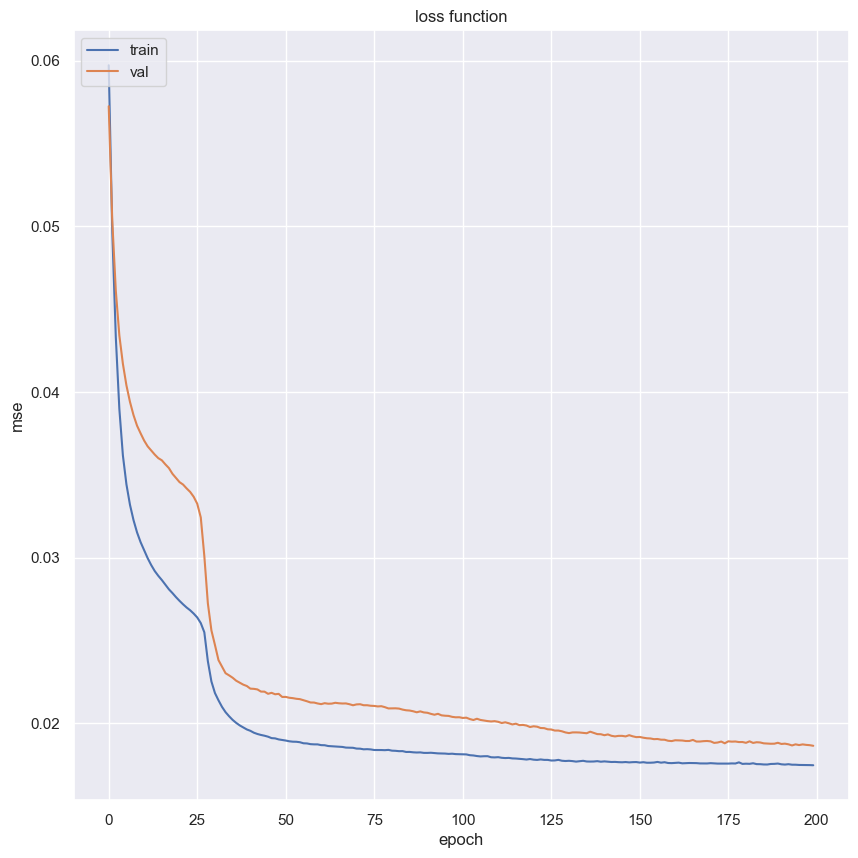

In [36]:
# summarize history for accuracy
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss function')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

#Evaluate model on test data



In [37]:
# Evaluate your model accuracy on the test data
loss_test = model.evaluate(X_test,y_test)

# Print accuracy
print('mse_test:', loss_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0175 
mse_test: 0.017471354454755783


we can see the model is again slightly overfitting, but what does this translate in terms of USD accuracy of our prediction?

#Plot error


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Text(0, 0.5, 'y_pred (dB)')

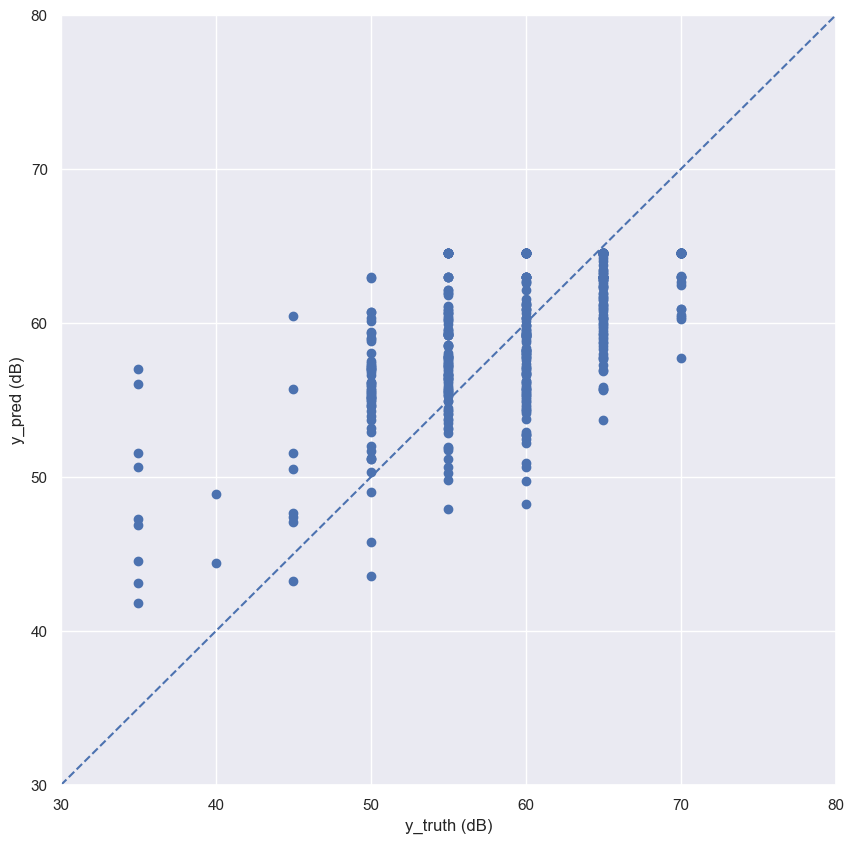

In [38]:
y_pred = scalerY.inverse_transform(model.predict(X_test))
y_truth = scalerY.inverse_transform(y_test)

plt.scatter(y_truth,y_pred)
plt.ylim((30,80))
plt.xlim((30,80))
plt.axline((0,0), slope = 1, ls="--")


plt.xlabel("y_truth (dB)")
plt.ylabel("y_pred (dB)")


In [39]:
def plot_comparison(x_val, pred, truth, xlab, ylab):
  fig, ax1 = plt.subplots(figsize = (10,10))
  ax1.plot(x_val, truth, color = "red", label = "truth",linestyle='None', marker = "o", markersize = 5)
  ax1.plot(x_val, pred, color = "blue", label = "pred",linestyle='None', marker = "o", markersize = 4, alpha = 0.5)

  ax1.set_xlabel(xlab)
  ax1.set_ylabel(ylab)
  ax1.legend()
  plt.title('Prediction Comparison')
  plt.show()

[ 9.99712958  1.43989593  0.46584176 50.          3.02177382  5.3921907
  2.17405881  2.27849697  0.92009586  4.15766316  0.35268512  3.33340099
  1.703764   23.1252828   2.09946131  2.37037104  4.98088155  3.68965363
  2.41161755  6.17536654  3.16337432  3.43838642  1.45718337  2.87340932
 31.70849178  2.83541755  4.03198762  5.18441526  5.23292104 47.87230385
  1.28100348  0.88679173  2.86117023  1.63864531  2.44526352  4.28063274
  7.52341216  0.9204634   3.46349298  2.02046833  1.44871936 12.37037602
  0.71931536  1.43476423  6.65213831  0.367143    5.69532354  1.21326047
  0.73804385  1.51508356  2.76668381  4.47002695  0.8515447   5.93774652
  1.45475048  6.70745712 17.31730701  6.38206621  4.70190885  1.26685639
  1.05949543  1.70921792  6.06234881  0.75117066  2.9954298   1.16840754
 19.28333777  0.8538266   2.92366109  0.78345697  2.95197348 31.64339537
  4.27636957  1.36439255  3.91630496 28.26269737  2.16331647  1.43683804
 44.59814605  7.02167693 40.02667819  0.91150251 26.

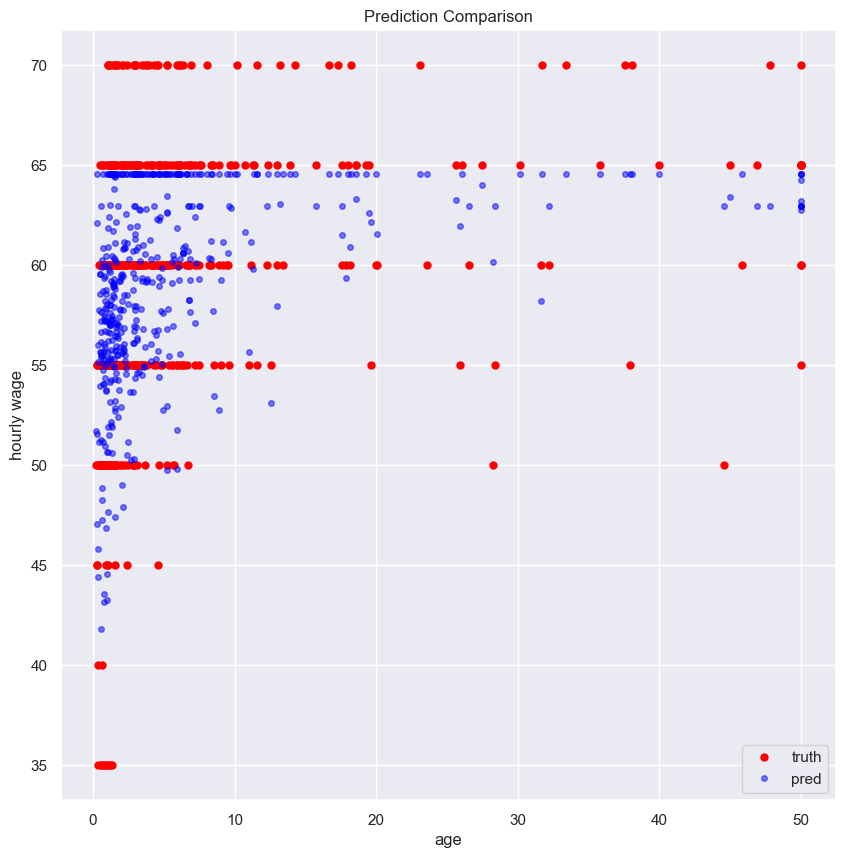

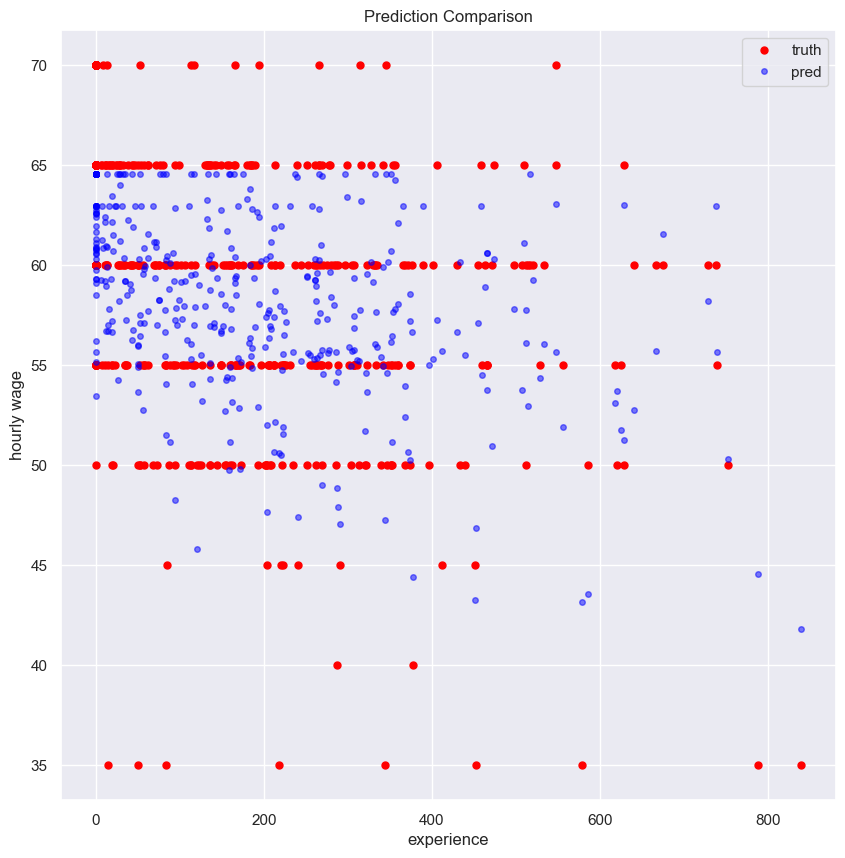

In [40]:
age_test = (scalerX.inverse_transform(X_test)[:,3])
print(age_test)

exp_test = (scalerX.inverse_transform(X_test)[:,2])

plot_comparison(age_test, y_pred, y_truth, "age", "hourly wage")
plot_comparison(exp_test, y_pred, y_truth,  "experience", "hourly wage")

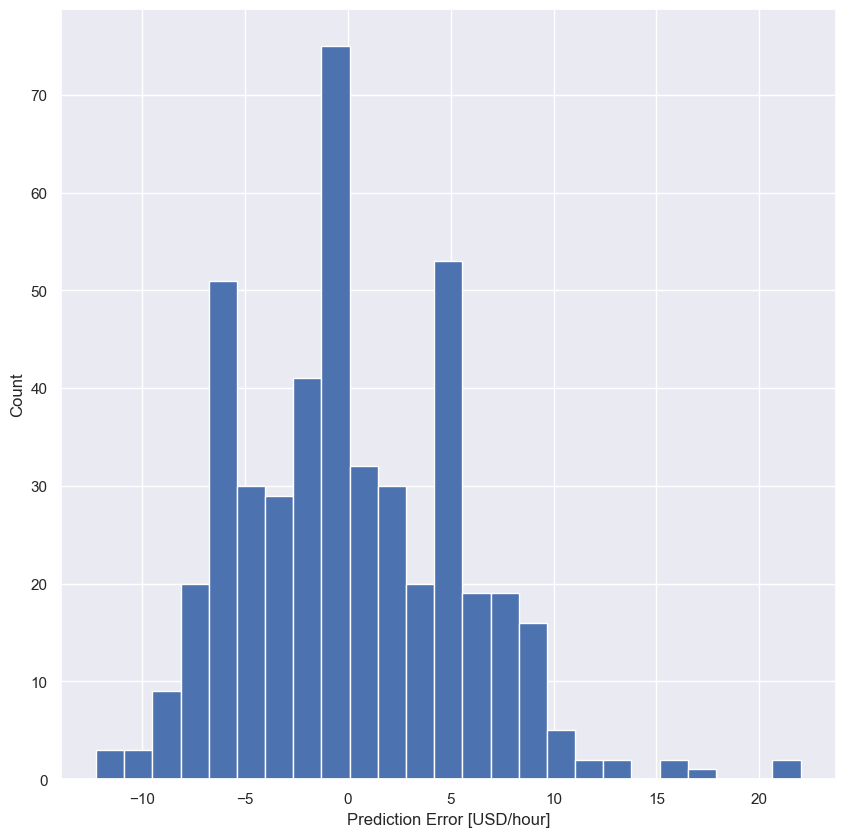

In [41]:
error = y_pred - y_truth
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [USD/hour]')
_ = plt.ylabel('Count')